### **Algorithme d'Apprentissages : Projet Foot - Vladimir Varenne-Welnovski**
Ce notebook est le rendu final pour le projet d'Algorithme d'Apprentissage : son but est d'explorer les solutions pour predire le resultat d'un match de foot.

Il se decompose en une partie d'exploration qualitative des donnees, puis en une partie prediction visant a tester differentes methodes pour arriver a predire avec le moins d'erreur possible le resultat des matchs de Ligue 1.

In [2]:
# Importation des library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Style global des graphs

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

#### **PARTIE 1 : EXPLORATION**
Voici les .csv que nous avons a notre disposition : 
- match_2013_2024.csv : La liste de tous les matchs avant le début de saison 2025-2026, avec le résultat associé
- match_2025.csv : La liste des matchs à prédire pour la saison 2025-2026, vous n’avez pas le résultat, il sera dévoilé après la fin du projet.
- sample_results.csv : un exemple de fichier de prédiction que j’attends pour tester votre modèle. À chaque id de match est associé un résultat (-1 0 ou 1)

- clubs_fr.csv : Une liste des clubs français avec quelques stats sur la constitution (récente) de l’équipe
- player_valuation_before_season.csv : Pour chaque joueur, sa valeur sur le marché, à une certaine date, à vous de transformer et d’utiliser cette information à bonne escient.
- player_appearance.csv : Un ensemble d’info simple sur chaque joueur pendant chaque match (nombre de buts, nombre de cartons)
- game_lineups.csv : La constitution des équipes pour chaque match, vous n’avez pas la constitution pour les matchs récents.
- game_events.csv :  Un ensemble d’actions pour chaque joueur pendant chaque match, peut compléter les informations sur un joueur, vous allez sûrement devoir aggreger des informations ce jeu (par exemple comptez le nombre de passe décisive, d’arrêt etc...)

In [7]:
df = pd.read_csv("data/matchs_2013_2024.csv")
df['results'].value_counts()

results
 1    2065
-1    1410
 0    1216
Name: count, dtype: int64

ValueError: Invalid format specifier '.1f%' for object of type 'float'

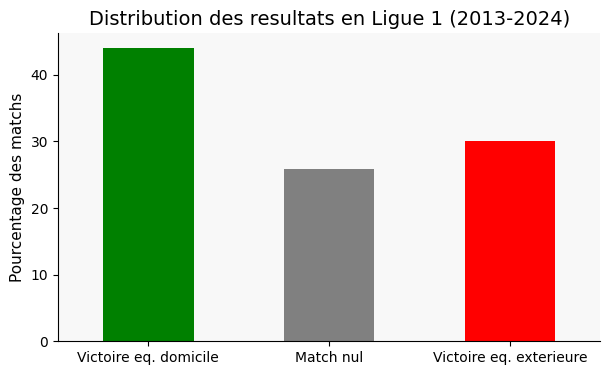

In [ ]:
fig, ax = plt.subplots(figsize = (7,4))
counts = df['results'].value_counts(normalize=True) * 100

counts = counts.reindex([1,0,-1])
counts.index = ["Victoire eq. domicile", "Match nul", "Victoire eq. exterieure"]

counts.plot(kind = "bar", ax=ax, color=["green", "grey", "red"], edgecolor = "none")

ax.set_title("Distribution des resultats en Ligue 1 (2013-2024)")
ax.set_ylabel("Pourcentage des matchs")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() +0.5),
                ha = "center", fontsize = 11)

plt.tight_layout()
plt.show()